In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('NH_ProviderInfo.csv')
df

,CMS Certification Number (CCN),Provider Name,Provider Address,City/Town,State,ZIP Code,Telephone Number,Provider SSA County Code,County/Parish,Urban,...,Number of Citations from Infection Control Inspections,Number of Fines,Total Amount of Fines in Dollars,Number of Payment Denials,Total Number of Penalties,Location,Latitude,Longitude,Geocoding Footnote,Processing Date
0,015009,"BURNS NURSING HOME, INC.",701 MONROE STREET NW,RUSSELLVILLE,AL,35653,2563324110,290,Franklin,N,...,NaN,0,0.0,0,0,"701 MONROE STREET NW,RUSSELLVILLE,AL,35653",34.5149,-87.736,NaN,2026-05-01
1,015010,COOSA VALLEY HEALTHCARE CENTER,260 WEST WALNUT STREET,SYLACAUGA,AL,35150,2562495604,600,Talladega,N,...,0.0,0,0.0,0,0,"260 WEST WALNUT STREET,SYLACAUGA,AL,35150",33.1637,-86.254,NaN,2026-05-01
2,015012,HIGHLANDS HEALTH AND REHAB,380 WOODS COVE ROAD,SCOTTSBORO,AL,35768,2562183708,350,Jackson,N,...,NaN,0,0.0,0,0,"380 WOODS COVE ROAD,SCOTTSBORO,AL,35768",34.6611,-86.047,NaN,2026-05-01
3,015014,EASTVIEW REHABILITATION & HEALTHCARE CENTER,7755 FOURTH AVENUE SOUTH,BIRMINGHAM,AL,35206,2058330146,360,Jefferson,Y,...,0.0,0,0.0,0,0,"7755 FOURTH AVENUE SOUTH,BIRMINGHAM,AL,35206",33.5595,-86.722,NaN,2026-05-01
4,015015,PLANTATION MANOR NURSING HOME,6450 OLD TUSCALOOSA HIGHWAY,MC CALLA,AL,35111,2054776161,360,Jefferson,Y,...,NaN,0,0.0,0,0,"6450 OLD TUSCALOOSA HIGHWAY,MC CALLA,AL,35111",33.3222,-87.034,NaN,2026-05-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14695,745055,MEMORIAL HEALTH CARE CENTER,212 NW 10TH ST,SEMINOLE,TX,79360,4327584877,542,Gaines,N,...,NaN,0,0.0,0,0,"212 NW 10TH ST,SEMINOLE,TX,79360",32.7206,-102.660,NaN,2026-05-01
14696,745056,Southern Oaks Therapy and Living Center,3350 Bonnie View Rd,Dallas,TX,75216,4693204400,390,Dallas,Y,...,NaN,0,0.0,0,0,"3350 Bonnie View Rd,Dallas,TX,75216",32.7183,-96.778,NaN,2026-05-01
14697,745057,Tuskegee Airmen Texas State Veterans Home,2200 JOE B RUSHING ROAD,FORT WORTH,TX,76119,5129819025,910,Tarrant,Y,...,NaN,2,28454.0,0,2,"2200 JOE B RUSHING ROAD,FORT WORTH,TX,76119",32.6723,-97.295,NaN,2026-05-01
14698,745058,THE HEIGHTS OF MAGNOLIA,150 CORPORATE WOODS DRIVE,MAGNOLIA,TX,77354,3462200070,801,Montgomery,Y,...,NaN,0,0.0,0,0,"150 CORPORATE WOODS DRIVE,MAGNOLIA,TX,77354",30.2213,-95.677,22.0,2026-05-01


In [8]:
import pandas as pd
from IPython.display import display

df = pd.read_csv('NH_ProviderInfo.csv', encoding='latin-1')

# ── select relevant columns ────────────────────────────────────────────────
cols = [
    'Provider Name',
    'State',
    'Ownership Type',
    'Overall Rating',
    'Health Inspection Rating',
    'Staffing Rating',
    'QM Rating',
    'Reported Total Nurse Staffing Hours per Resident per Day',
    'Total nursing staff turnover',
    'Rating Cycle 1 Total Number of Health Deficiencies',
    'Total Amount of Fines in Dollars',
    'Total Number of Penalties',
    'Number of Certified Beds',
    'Chain Name',
    'Number of Facilities in Chain',
    'Abuse Icon',
    'Special Focus Status'
]

df_clean = df[cols].copy()

# ── top 20 worst overall rating ────────────────────────────────────────────
worst = (df_clean
         .dropna(subset=['Overall Rating'])
         .sort_values('Overall Rating', ascending=True)
         .head(20)
         .reset_index(drop=True))

worst.index = range(1, 21)

# ── format display copy ────────────────────────────────────────────────────
worst_display = worst.copy()
worst_display['Ownership Type'] = (worst_display['Ownership Type']
    .str.replace('For profit - ', 'FP - ', regex=False)
    .str.replace('Non profit - ', 'NP - ', regex=False))
worst_display['Total Amount of Fines in Dollars'] = (
    worst_display['Total Amount of Fines in Dollars']
    .fillna(0).map('${:,.0f}'.format))

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 35)
pd.set_option('display.width', 200)

# ── rendered table ─────────────────────────────────────────────────────────
display(
    worst_display[[
        'Provider Name', 'State', 'Ownership Type',
        'Overall Rating', 'Health Inspection Rating',
        'Staffing Rating', 'QM Rating',
        'Rating Cycle 1 Total Number of Health Deficiencies',
        'Total Amount of Fines in Dollars',
        'Total Number of Penalties',
        'Special Focus Status', 'Abuse Icon',
        'Chain Name', 'Number of Facilities in Chain'
    ]].style
    .set_caption('Top 20 Worst Nursing Homes')
    .highlight_min(
        subset=['Overall Rating', 'Health Inspection Rating', 'Staffing Rating'],
        color='#ffcccc')
    .highlight_max(
        subset=['Rating Cycle 1 Total Number of Health Deficiencies', 'Total Number of Penalties'],
        color='#ffcccc')
    .set_properties(**{'font-size': '11px'})
)

# ── summary stats ──────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("SUMMARY — WORST 20")
print("=" * 60)
print(f"For-profit count:    {worst['Ownership Type'].str.contains('For profit', case=False, na=False).sum()}")
print(f"Nonprofit count:     {worst['Ownership Type'].str.contains('Non profit', case=False, na=False).sum()}")
print(f"Government count:    {worst['Ownership Type'].str.contains('Government', case=False, na=False).sum()}")
print(f"Part of a chain:     {worst['Chain Name'].notna().sum()}")
print(f"Abuse icon flagged:  {worst['Abuse Icon'].notna().sum()}")
print(f"Special focus:       {worst['Special Focus Status'].notna().sum()}")
print(f"Avg deficiencies:    {worst['Rating Cycle 1 Total Number of Health Deficiencies'].mean():.1f}")
print(f"Avg fines ($):       {worst['Total Amount of Fines in Dollars'].mean():,.0f}")
print(f"Avg penalties:       {worst['Total Number of Penalties'].mean():.1f}")
print(f"Avg nurse hrs/day:   {worst['Reported Total Nurse Staffing Hours per Resident per Day'].mean():.2f}")

,Provider Name,State,Ownership Type,Overall Rating,Health Inspection Rating,Staffing Rating,QM Rating,Rating Cycle 1 Total Number of Health Deficiencies,Total Amount of Fines in Dollars,Total Number of Penalties,Special Focus Status,Abuse Icon,Chain Name,Number of Facilities in Chain
1,Mont Belvieu Rehabilitation & Healthcare Center,TX,FP - Limited Liability company,1.000000,2.000000,1.000000,4.000000,9.000000,"$41,789",3,nan,N,nan,nan
2,Avir at Johnson City,TX,FP - Limited Liability company,1.000000,2.000000,1.000000,3.000000,7.000000,"$74,691",3,nan,N,AVIR HEALTH GROUP,117.000000
3,Sylan Shores Health and Wellness,TX,Government - Hospital district,1.000000,2.000000,1.000000,3.000000,4.000000,"$8,281",1,nan,Y,ML HEALTHCARE,6.000000
4,BLUEBONNET POINT WELLNESS,TX,FP - Corporation,1.000000,2.000000,1.000000,2.000000,11.000000,"$181,063",5,nan,N,CREATIVE SOLUTIONS IN HEALTHCARE,149.000000
5,RIVER CITY CENTER,AL,FP - Corporation,1.000000,1.000000,4.000000,4.000000,6.000000,$0,0,nan,N,GENESIS HEALTHCARE,187.000000
6,SHADESCREST HEALTH CARE CENTER,AL,FP - Individual,1.000000,1.000000,4.000000,3.000000,13.000000,$0,0,nan,N,nan,nan
7,MERRY WOOD LODGE,AL,FP - Limited Liability company,1.000000,1.000000,3.000000,4.000000,8.000000,"$182,968",2,SFF Candidate,Y,GENESIS HEALTHCARE,187.000000
8,"WETUMPKA HEALTH AND REHABILITATION, LLC",AL,FP - Corporation,1.000000,1.000000,3.000000,2.000000,15.000000,$0,0,nan,N,NHS MANAGEMENT,43.000000
9,AVIR AT LINDALE,TX,Government - Hospital district,1.000000,1.000000,2.000000,3.000000,13.000000,"$767,771",6,nan,Y,AVIR HEALTH GROUP,117.000000
10,Optalis Health & Rehabilitation at Kent-Crossing,MI,FP - Corporation,1.000000,1.000000,3.000000,4.000000,35.000000,$0,0,nan,N,OPTALIS HEALTH & REHABILITATION,37.000000



SUMMARY — WORST 20
For-profit count:    16
Nonprofit count:     1
Government count:    3
Part of a chain:     16
Abuse icon flagged:  20
Special focus:       2
Avg deficiencies:    13.4
Avg fines ($):       91,079
Avg penalties:       1.4
Avg nurse hrs/day:   3.49


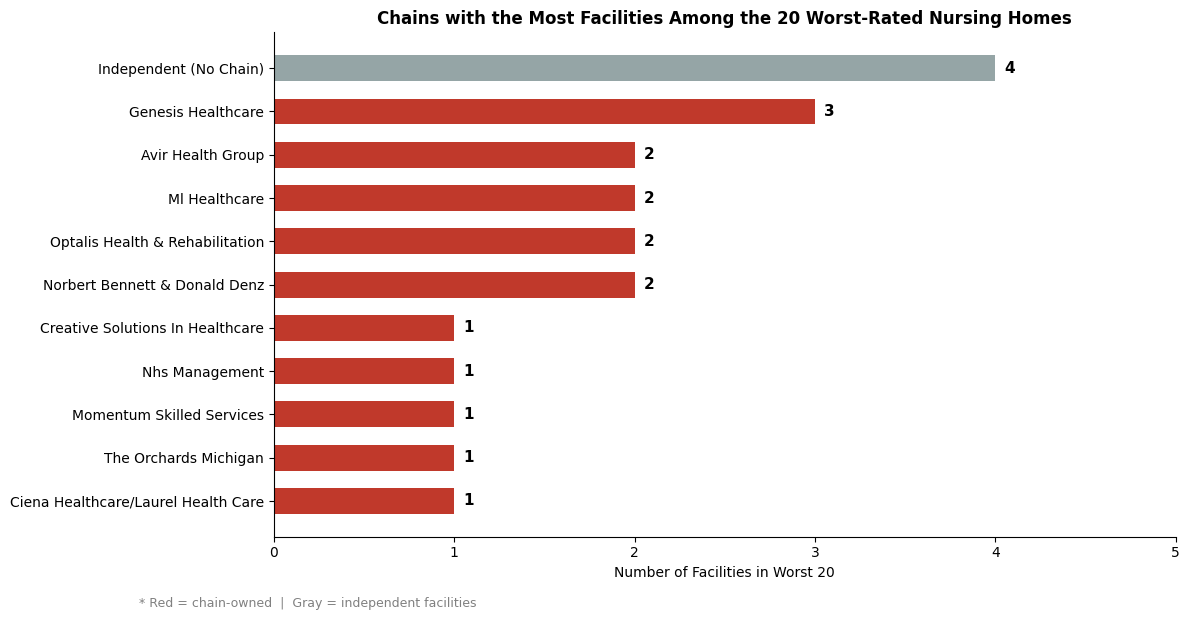

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# chain data from worst 20
chains = worst['Chain Name'].fillna('Independent (No Chain)')

chain_counts = chains.value_counts().reset_index()
chain_counts.columns = ['Chain Name', 'Count']

# shorten long names for display
chain_counts['Chain Name'] = chain_counts['Chain Name'].str.title()

fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#C0392B' if c != 'Independent (No Chain)' else '#95A5A6' 
          for c in chain_counts['Chain Name']]

bars = ax.barh(chain_counts['Chain Name'], chain_counts['Count'], color=colors, height=0.6)
ax.invert_yaxis()
ax.set_xlabel('Number of Facilities in Worst 20')
ax.set_title('Chains with the Most Facilities Among the 20 Worst-Rated Nursing Homes', 
             fontsize=12, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)

# add count labels
for bar, count in zip(bars, chain_counts['Count']):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
            str(count), va='center', fontsize=11, fontweight='bold')

ax.set_xlim(0, chain_counts['Count'].max() + 1)

# add note
fig.text(0.12, -0.02, 
         '* Red = chain-owned  |  Gray = independent facilities', 
         fontsize=9, color='gray')

plt.tight_layout()
plt.savefig('chart_worst20_chains.png', dpi=150, bbox_inches='tight')
plt.show()

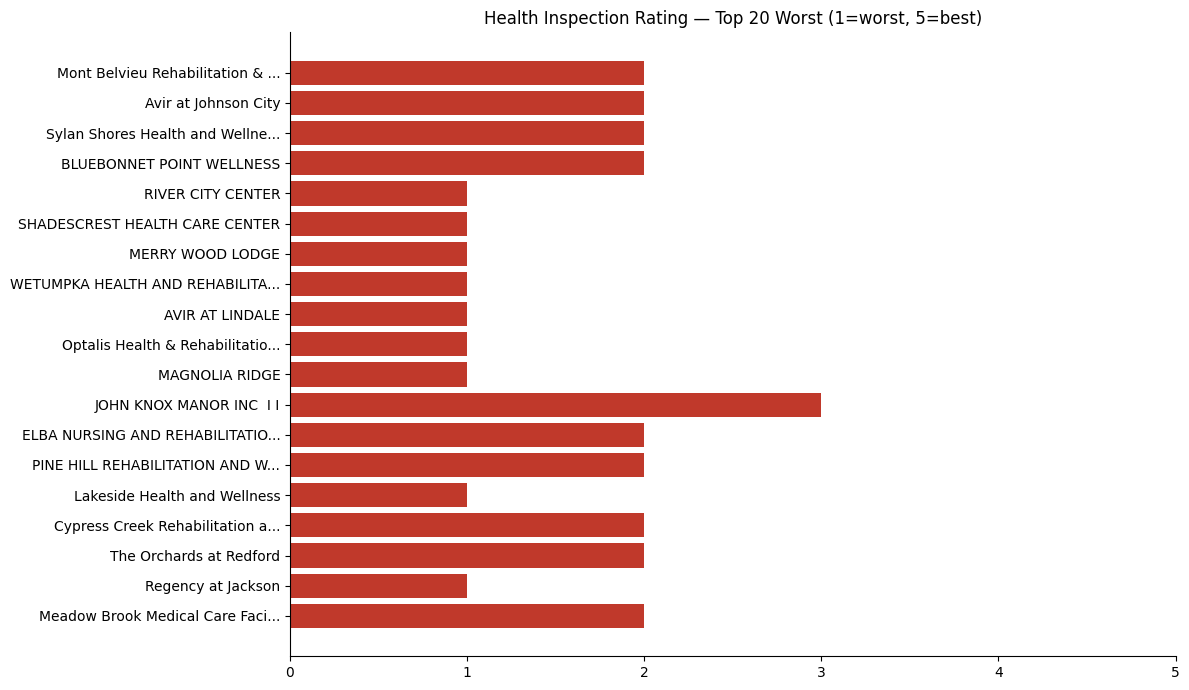

In [9]:
import matplotlib.pyplot as plt

names = [n[:30] + '...' if len(n) > 30 else n for n in worst['Provider Name']]

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(names, worst['Health Inspection Rating'], color='#C0392B')
ax.invert_yaxis()
ax.set_title('Health Inspection Rating — Top 20 Worst (1=worst, 5=best)')
ax.set_xlim(0, 5)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('chart1_inspection_rating.png', dpi=150, bbox_inches='tight')
plt.show()

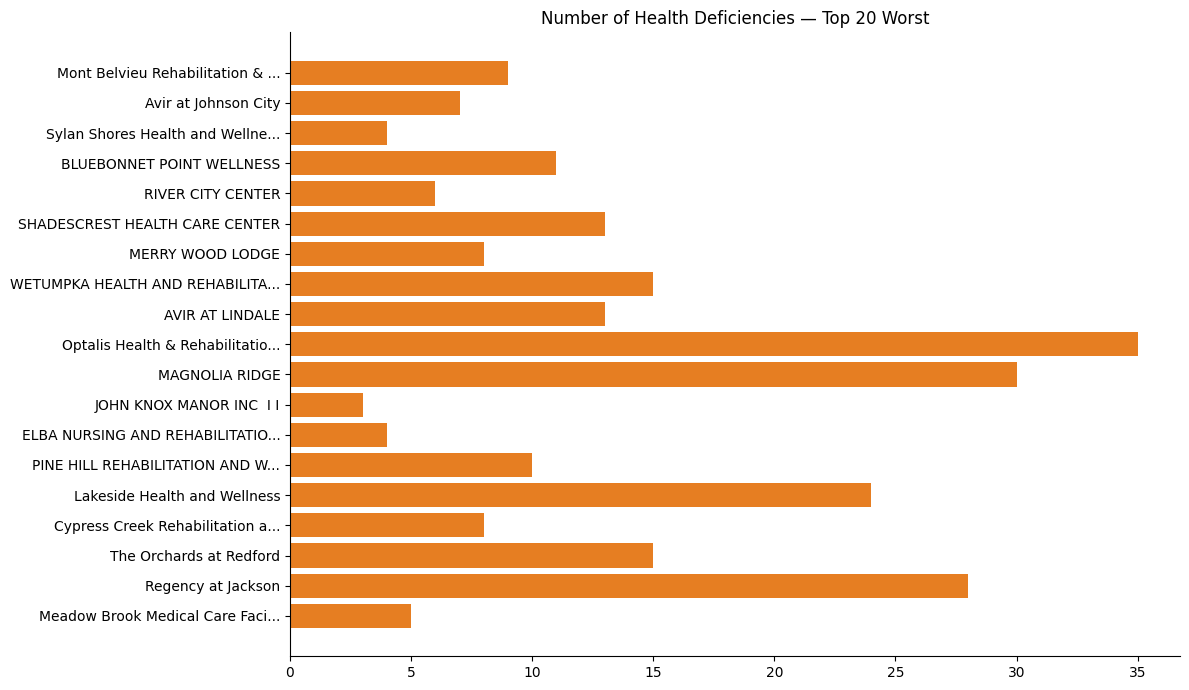

In [10]:
fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(names, worst['Rating Cycle 1 Total Number of Health Deficiencies'], color='#E67E22')
ax.invert_yaxis()
ax.set_title('Number of Health Deficiencies — Top 20 Worst')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('chart2_deficiencies.png', dpi=150, bbox_inches='tight')
plt.show()

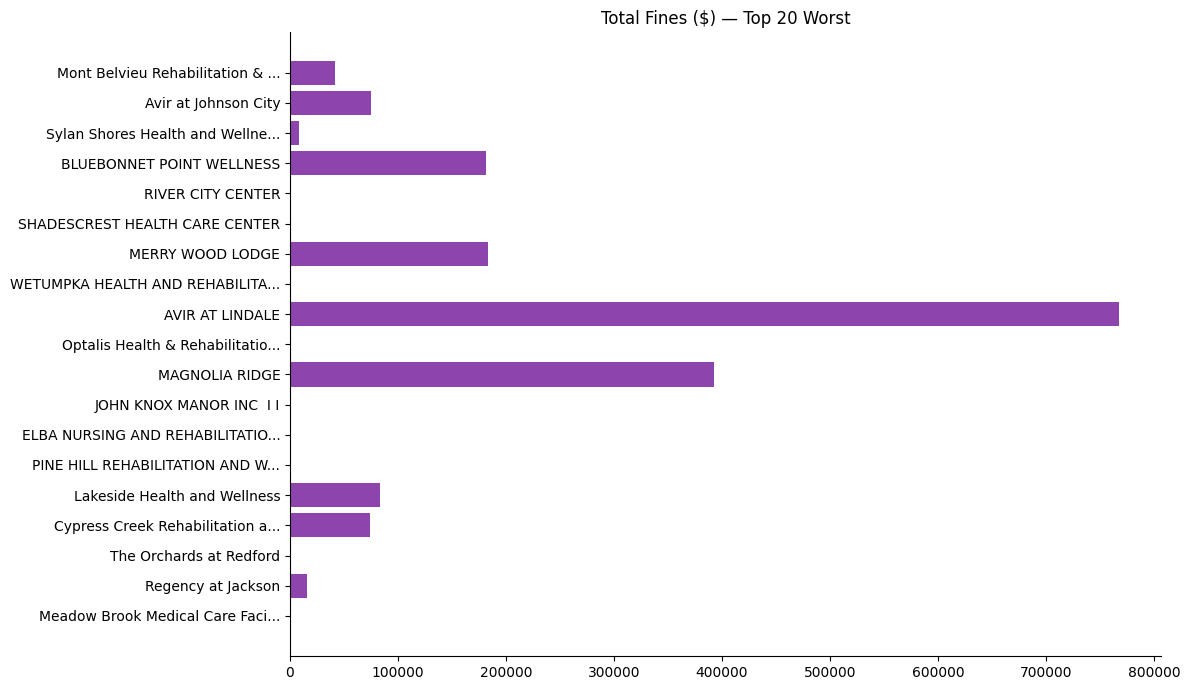

In [11]:
fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(names, worst['Total Amount of Fines in Dollars'].fillna(0), color='#8E44AD')
ax.invert_yaxis()
ax.set_title('Total Fines ($) — Top 20 Worst')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('chart4_fines.png', dpi=150, bbox_inches='tight')
plt.show()